In [1]:
import sys
print(sys.executable)

import tensorflow as tf
print(tf.__version__)

C:\Users\student\anaconda3\envs\darkflow\python.exe
1.15.0


In [3]:
import os

os.chdir(r"C:\Users\student\darkflow")
print(os.getcwd())

C:\Users\student\darkflow


In [4]:
import os

print(os.path.exists("bin/yolov2.weights"))

True


In [5]:
from darkflow.net.build import TFNet

The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.











In [6]:
from darkflow.net.build import TFNet
print("Darkflow imported successfully!")

Darkflow imported successfully!


In [7]:
from darkflow.net.build import TFNet

options = {
    "model": "cfg/yolo.cfg",
    "load": "bin/yolov2.weights",
    "threshold": 0.25
}

tfnet = TFNet(options)

Parsing cfg/yolo.cfg
Loading bin/yolov2.weights ...
Successfully identified 203934260 bytes
Finished in 0.018950223922729492s
Model has a coco model name, loading coco labels.

Building net ...

Source | Train? | Layer description                | Output size
-------+--------+----------------------------------+---------------



       |        | input                            | (?, 608, 608, 3)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 608, 608, 32)



C:\Users\student\darkflow\darkflow\dark\darknet.py:54: UserWarning: ./cfg/yolov2.cfg not found, use cfg/yolo.cfg instead
  cfg_path, FLAGS.model))


 Load  |  Yep!  | maxp 2x2p0_2                     | (?, 304, 304, 32)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 304, 304, 64)
 Load  |  Yep!  | maxp 2x2p0_2                     | (?, 152, 152, 64)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 152, 152, 128)
 Load  |  Yep!  | conv 1x1p0_1  +bnorm  leaky      | (?, 152, 152, 64)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 152, 152, 128)
 Load  |  Yep!  | maxp 2x2p0_2                     | (?, 76, 76, 128)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 76, 76, 256)
 Load  |  Yep!  | conv 1x1p0_1  +bnorm  leaky      | (?, 76, 76, 128)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 76, 76, 256)
 Load  |  Yep!  | maxp 2x2p0_2                     | (?, 38, 38, 256)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 38, 38, 512)
 Load  |  Yep!  | conv 1x1p0_1  +bnorm  leaky      | (?, 38, 38, 256)
 Load  |  Yep!  | conv 3x3p1_1  +bnorm  leaky      | (?, 38, 38, 512)
 Load  |  Ye

In [9]:
import matplotlib.pyplot as plt
print("Matplotlib installed successfully")

Matplotlib installed successfully


In [10]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("sample_img/sample_dog.jpg")

result = tfnet.return_predict(img)

print(result)

[{'label': 'bicycle', 'confidence': 0.8483924, 'topleft': {'x': 80, 'y': 114}, 'bottomright': {'x': 555, 'y': 466}}, {'label': 'motorbike', 'confidence': 0.28164315, 'topleft': {'x': 59, 'y': 76}, 'bottomright': {'x': 113, 'y': 124}}, {'label': 'truck', 'confidence': 0.79957765, 'topleft': {'x': 462, 'y': 81}, 'bottomright': {'x': 694, 'y': 167}}, {'label': 'dog', 'confidence': 0.76919776, 'topleft': {'x': 136, 'y': 214}, 'bottomright': {'x': 322, 'y': 539}}]


In [12]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("sample_img/sample_dog.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)



In [13]:
img.shape

(576, 768, 3)

In [15]:
result=tfnet.return_predict(img)

In [16]:
result

[{'label': 'bicycle',
  'confidence': 0.8021632,
  'topleft': {'x': 84, 'y': 115},
  'bottomright': {'x': 551, 'y': 463}},
 {'label': 'truck',
  'confidence': 0.8223033,
  'topleft': {'x': 461, 'y': 82},
  'bottomright': {'x': 698, 'y': 168}},
 {'label': 'dog',
  'confidence': 0.8208252,
  'topleft': {'x': 130, 'y': 215},
  'bottomright': {'x': 326, 'y': 535}}]

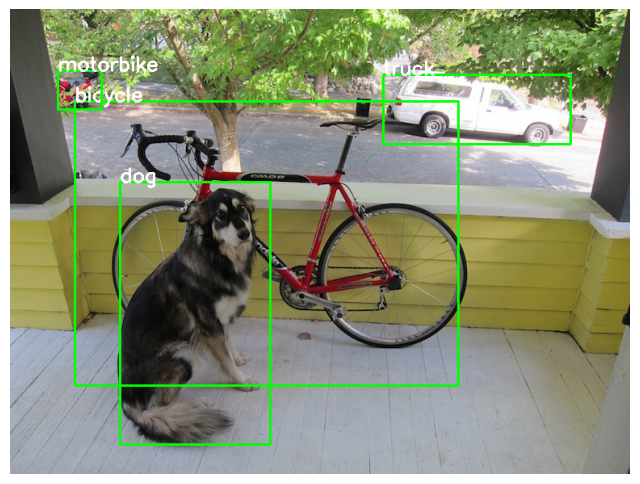

In [18]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("sample_img/sample_dog.jpg")

# Run detection
result = tfnet.return_predict(img)

# Draw bounding boxes
for r in result:
    tl = (r['topleft']['x'], r['topleft']['y'])
    br = (r['bottomright']['x'], r['bottomright']['y'])
    label = r['label']

    cv2.rectangle(img, tl, br, (0, 255, 0), 2)
    cv2.putText(img, label, tl,
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (255, 255, 255), 2)

# Convert BGR to RGB for matplotlib
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 12))
plt.imshow(img)
plt.axis("off")
plt.show()